1/4: Loading the indexed CSV and Palette...
2/4: Calculating RA and DEC from X, Y, Z...
3/4: Filtering the Slice (90 < RA < 280 and -5 < DEC < 5)...
Kept 2,404,583 galaxies out of 10,053,068.
Saved mini-CSV for OpenSpace: desi_slice_90_280.csv
4/4: Generating the high-res plot...
SUCCESS! Slice plot saved as desi_slice_plot.png


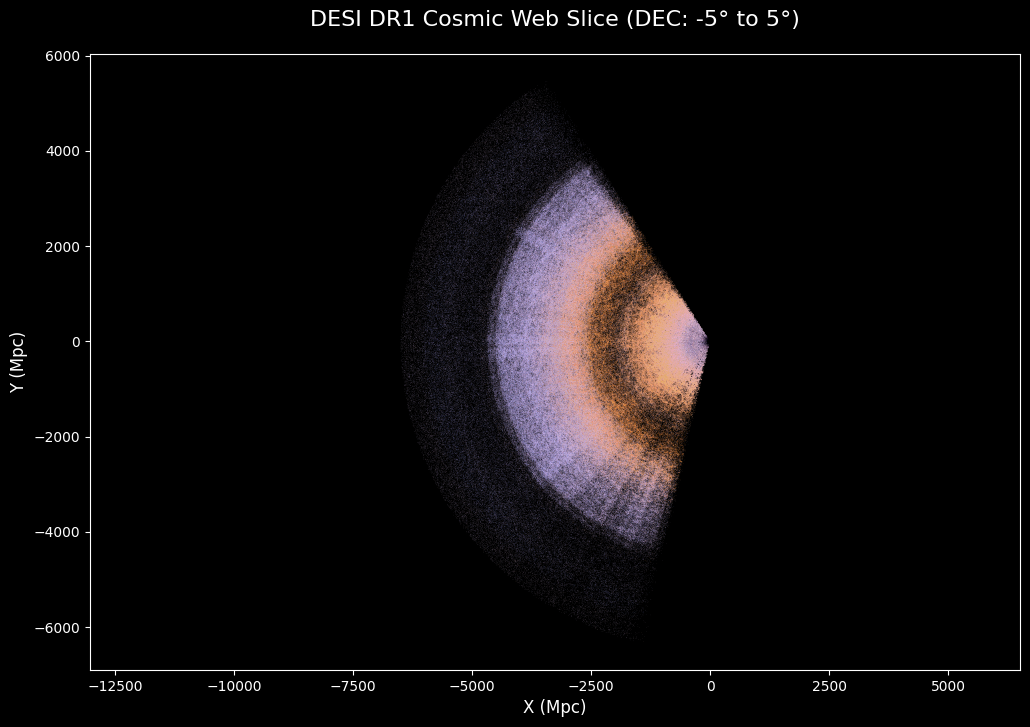

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Load the Data ---
print("1/4: Loading the indexed CSV and Palette...")
df = pd.read_csv("/users/PCON0003/ulricclaar/desi-openspace-visualization/openspace_assets/desi_catalog_indexed_0-2-0.csv")

# Load the 1000 colors from the cmap file
# We skip the first line because it just contains the header '1000'
palette = np.loadtxt("/users/PCON0003/ulricclaar/desi-openspace-visualization/openspace_assets/lupton_palette.cmap", skiprows=1)

# The cmap has 4 columns (R, G, B, Alpha). We just need the R, G, B floats for plotting
rgb_map = palette[:, :3]

# --- 2. Calculate RA and DEC ---
print("2/4: Calculating RA and DEC from X, Y, Z...")
# Calculate radial distance (r)
r = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2)

# Calculate Declination (degrees)
dec = np.arcsin(df['z'] / r) * (180.0 / np.pi)

# Calculate Right Ascension (degrees)
ra = np.arctan2(df['y'], df['x']) * (180.0 / np.pi)
ra = (ra + 360) % 360  # Convert the angles to a clean 0-360 degree range

# --- 3. Filter the Slice ---
print("3/4: Filtering the Slice (90 < RA < 280 and -5 < DEC < 5)...")
# Create the bounding box mask
mask = (ra > 90) & (ra < 280) & (dec > -5) & (dec < 5)
slice_df = df[mask].copy()

# Look up the actual RGB colors for just these filtered points using their color_id
point_colors = rgb_map[slice_df['color_id'].values]

print(f"Kept {len(slice_df):,} galaxies out of {len(df):,}.")

# Save an OpenSpace-ready CSV of JUST this slice
slice_df.to_csv("desi_slice_90_280.csv", index=False)
print("Saved mini-CSV for OpenSpace: desi_slice_90_280.csv")

# --- 4. Plot the Cosmic Web ---
print("4/4: Generating the high-res plot...")
plt.style.use('dark_background')
plt.figure(figsize=(12, 8))

# Because DEC is restricted to a tight 10-degree band across the equator, 
# plotting X vs Y gives us a perfect top-down 2D wedge of the universe.
# We set 's' (size) very small to let the dense structures pop.
plt.scatter(slice_df['x'], slice_df['y'], c=point_colors, s=0.1, edgecolor='none', alpha=0.3)

plt.title("DESI DR1 Cosmic Web Slice (DEC: -5° to 5°)", fontsize=16, color='white', pad=20)
plt.xlabel("X (Mpc)", fontsize=12)
plt.ylabel("Y (Mpc)", fontsize=12)

# This forces the X and Y axes to use the same scale so the universe doesn't look squished
plt.axis('equal') 

# Save it as an image file directly to your folder
plt.savefig("desi_slice_plot.png", dpi=400, bbox_inches='tight')
print("SUCCESS! Slice plot saved as desi_slice_plot.png")